# Chapitre 8 — Préparer les données pour la modélisation (feature engineering)

**Cours : Analyse et traitement des données** · Auteur : *Issa Gueye*

## Objectifs

- **Encoder** les variables catégorielles (one-hot, ordinal).
- **Mettre à l'échelle** les variables numériques (standardisation, min-max, robuste) et **transformer** (log, Box-Cox/Yeo-Johnson).
- **Créer** des variables utiles (ratios, dates, discrétisation, interactions).
- Éviter la **fuite de données** grâce aux `Pipeline` et `ColumnTransformer` de scikit-learn.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import (MinMaxScaler, OneHotEncoder, OrdinalEncoder, PowerTransformer, RobustScaler,
                                   StandardScaler)

DATA = next(p for p in [Path("data/brutes"), Path("../data/brutes"), Path("../../data/brutes")] if p.exists())
menages = pd.read_csv(DATA / "enquete_menages.csv")
menages.loc[menages["taille_menage"] == 99, "taille_menage"] = np.nan

**Tâche fil rouge** : prédire si un ménage **utilise le mobile money** (`Oui`/`Non`) à partir de ses caractéristiques.

## 1. Pourquoi préparer ?

Les algorithmes ne comprennent que des **nombres**, sont souvent sensibles à l'**échelle** des variables
(distances, régularisation, descente de gradient) et ne tolèrent pas les **NaN** (pour la plupart).

## 2. Encoder les variables catégorielles

| Méthode | Pour | Exemple |
|---|---|---|
| **One-hot** (indicatrices) | nominales | région → `region_Dakar`, `region_Thiès`, … |
| **Ordinal** (entiers ordonnés) | ordinales | éducation : Aucun=0 < … < Supérieur=4 |
| Target / fréquence | très nombreuses modalités | à manier avec précaution (fuite) |

In [2]:
exemple = menages[["region", "education_chef"]].head(5)
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore").set_output(transform="pandas")
print(ohe.fit_transform(exemple[["region"]]))

ordre = [["Aucun", "Coranique", "Primaire", "Secondaire", "Supérieur"]]
ordinal = OrdinalEncoder(categories=ordre).set_output(transform="pandas")
print(pd.concat([exemple["education_chef"], ordinal.fit_transform(exemple[["education_chef"]])], axis=1))

   region_Dakar  region_Diourbel  region_Thiès
0           0.0              1.0           0.0
1           0.0              0.0           1.0
2           1.0              0.0           0.0
3           1.0              0.0           0.0
4           1.0              0.0           0.0
  education_chef  education_chef
0          Aucun             0.0
1       Primaire             2.0
2          Aucun             0.0
3       Primaire             2.0
4      Supérieur             4.0


> ⚠️ Ne jamais encoder une variable **nominale** en 1, 2, 3… : le modèle croirait que « Thiès (2) » est entre
> « Dakar (1) » et « Kaolack (3) ».
> `handle_unknown="ignore"` évite une erreur si une modalité nouvelle apparaît en production.

## 3. Mise à l'échelle et transformations

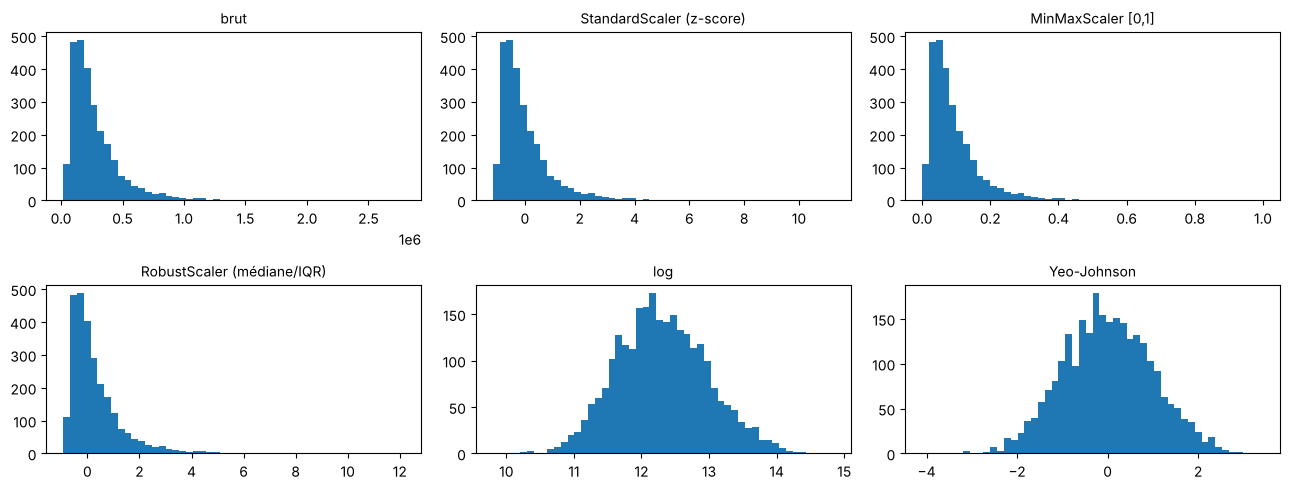

In [3]:
x = menages[["revenu_mensuel_fcfa"]].dropna()
transfos = {
    "brut": x.values.ravel(),
    "StandardScaler (z-score)": StandardScaler().fit_transform(x).ravel(),
    "MinMaxScaler [0,1]": MinMaxScaler().fit_transform(x).ravel(),
    "RobustScaler (médiane/IQR)": RobustScaler().fit_transform(x).ravel(),
    "log": np.log(x.values.ravel()),
    "Yeo-Johnson": PowerTransformer(method="yeo-johnson").fit_transform(x).ravel(),
}
fig, axes = plt.subplots(2, 3, figsize=(13, 5))
for ax, (nom, v) in zip(axes.ravel(), transfos.items()):
    ax.hist(v, bins=50); ax.set_title(nom, fontsize=10)
plt.tight_layout(); plt.show()

- Les *scalers* **changent l'échelle, pas la forme** de la distribution.
- `log` / `PowerTransformer` **changent la forme** (réduisent l'asymétrie).
- `RobustScaler` est peu sensible aux valeurs extrêmes.
- Les modèles à base d'**arbres** (forêts, boosting) n'ont pas besoin de mise à l'échelle.

## 4. Créer des variables (feature engineering)

C'est souvent **là** que se joue la performance : traduire la connaissance métier en variables.

In [4]:
fe = menages.assign(
    revenu_par_personne=lambda d: d["revenu_mensuel_fcfa"] / d["taille_menage"],          # ratio
    taux_depense=lambda d: d["depenses_mensuelles_fcfa"] / d["revenu_mensuel_fcfa"],      # ratio
    log_depenses=lambda d: np.log(d["depenses_mensuelles_fcfa"]),                         # transformation
    tranche_age=lambda d: pd.cut(d["age_chef"], [0, 30, 45, 60, 120],
                                 labels=["<30", "30-44", "45-59", "60+"]),                # discrétisation
    urbain_x_internet=lambda d: ((d["milieu"] == "Urbain") & (d["acces_internet"] == "Oui")).astype(int),  # interaction
    revenu_manquant=lambda d: d["revenu_mensuel_fcfa"].isna().astype(int),                # indicateur de manquant
)
fe[["revenu_par_personne", "taux_depense", "tranche_age", "urbain_x_internet", "revenu_manquant"]].head()

,revenu_par_personne,taux_depense,tranche_age,urbain_x_internet,revenu_manquant
0,9833.333333,0.711864,30-44,0,0
1,NaN,NaN,60+,0,1
2,65625.000000,0.931429,30-44,0,0
3,31000.000000,0.800000,45-59,0,0
4,145000.000000,0.788506,30-44,1,0


Pour des **dates** : année, mois, jour de la semaine, jour férié, saison (hivernage), temps écoulé depuis un événement ;
pour des variables **cycliques** (mois, heure) : encodage $\sin(2\pi m/12)$, $\cos(2\pi m/12)$ pour que décembre soit proche de janvier.

## 5. La fuite de données (*data leakage*) — l'erreur n°1

**Fuite** = utiliser, pendant l'entraînement, une information qui ne sera pas disponible au moment de la prédiction
→ performance **sur-estimée**, déception en production.

Formes classiques :
1. Ajuster un *scaler* / imputeur / encodeur **sur toutes les données** avant de séparer train/test.
2. Variable qui **contient la cible** (ex. « a reçu un bonus mobile money » pour prédire « utilise le mobile money »).
3. Information **future** dans une série temporelle (ne pas mélanger aléatoirement des données temporelles).
4. Doublons présents à la fois dans le train et le test.

Démonstration spectaculaire : sélectionner des variables **avant** la validation croisée sur des données **purement aléatoires**.

In [5]:
from sklearn.feature_selection import SelectKBest, f_classif

rng = np.random.default_rng(0)
X_bruit = rng.normal(size=(100, 5_000))        # 5000 variables de bruit
y_bruit = rng.integers(0, 2, 100)              # cible aléatoire : AUCUN signal possible

# ❌ Mauvais : sélection sur tout le jeu, puis validation croisée
X_sel = SelectKBest(f_classif, k=20).fit_transform(X_bruit, y_bruit)
mauvais = cross_val_score(LogisticRegression(max_iter=1000), X_sel, y_bruit, cv=5).mean()
# ✅ Bon : sélection DANS le pipeline, refaite sur chaque pli d'entraînement
bon = cross_val_score(make_pipeline(SelectKBest(f_classif, k=20), LogisticRegression(max_iter=1000)),
                      X_bruit, y_bruit, cv=5).mean()
print(f"Exactitude avec fuite : {mauvais:.2f}   |   sans fuite : {bon:.2f}   (hasard = 0.50)")

Exactitude avec fuite : 0.85   |   sans fuite : 0.48   (hasard = 0.50)


## 6. La solution : `Pipeline` + `ColumnTransformer`

Chaque étape est **ajustée sur l'entraînement seulement** (`fit`), puis **appliquée** (`transform`) au test :

```text
              ┌─ numériques  : imputation médiane → log/Yeo-Johnson → standardisation ─┐
 X (brut) ───►├─ ordinales   : imputation mode    → encodage ordinal                   ├──► modèle
              └─ nominales   : imputation mode    → one-hot                            ┘
```

In [6]:
cible = (menages["utilise_mobile_money"] == "Oui").astype(int)
X = menages.drop(columns=["id_menage", "utilise_mobile_money"])

num_cols = ["taille_menage", "age_chef", "revenu_mensuel_fcfa", "depenses_mensuelles_fcfa"]
ord_cols = ["education_chef"]
nom_cols = ["region", "milieu", "sexe_chef", "acces_electricite", "acces_internet"]

preparation = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median", add_indicator=True)),
                      ("forme", PowerTransformer(method="yeo-johnson"))]), num_cols),   # PowerTransformer standardise aussi
    ("ord", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("enc", OrdinalEncoder(categories=ordre)),
                      ("std", StandardScaler())]), ord_cols),
    ("nom", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("ohe", OneHotEncoder(handle_unknown="ignore", drop="if_binary"))]), nom_cols),
], verbose_feature_names_out=False)

modele = Pipeline([("prep", preparation), ("clf", LogisticRegression(max_iter=1000))])

X_train, X_test, y_train, y_test = train_test_split(X, cible, test_size=0.25, stratify=cible, random_state=42)
modele.fit(X_train, y_train)
print(f"Exactitude test : {modele.score(X_test, y_test):.3f}  (classe majoritaire : {max(y_test.mean(), 1 - y_test.mean()):.3f})")

Exactitude test : 0.652  (classe majoritaire : 0.645)


In [7]:
modele  # affichage interactif du pipeline dans Jupyter

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['region','milieu','taille_menage',...,'depenses_mensuelles_fcfa', 'acces_electricite','acces_internet']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It

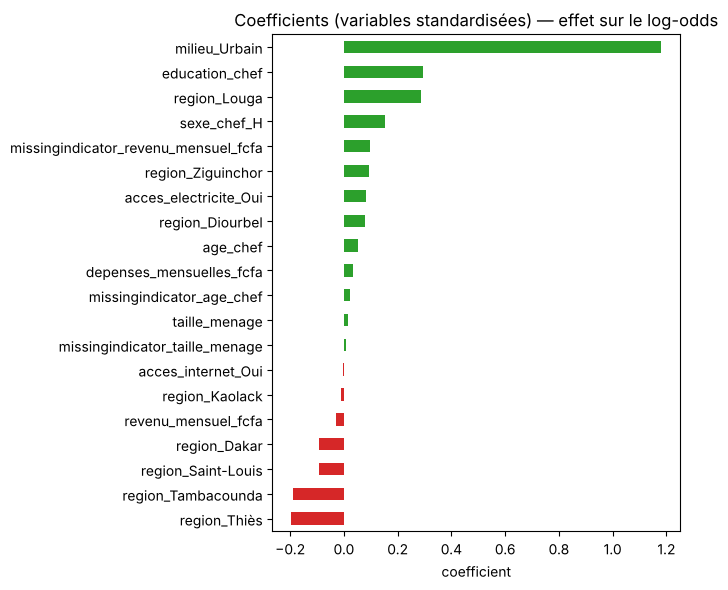

In [8]:
noms = modele.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(modele.named_steps["clf"].coef_[0], index=noms).sort_values()
ax = coefs.plot(kind="barh", figsize=(7, 6), color=np.where(coefs > 0, "tab:green", "tab:red"))
ax.set(title="Coefficients (variables standardisées) — effet sur le log-odds", xlabel="coefficient")
plt.tight_layout(); plt.show()

Avantages du pipeline :
- **pas de fuite** (tout est appris sur le train) ;
- **un seul objet** à sauvegarder (`joblib.dump(modele, "modele.joblib")`) et à appliquer à de nouvelles données brutes ;
- compatible avec la **validation croisée** et la recherche d'hyperparamètres (`GridSearchCV`).

In [9]:
scores = cross_val_score(modele, X, cible, cv=5, scoring="roc_auc")
print(f"AUC ROC en validation croisée 5 plis : {scores.mean():.3f} ± {scores.std():.3f}")

AUC ROC en validation croisée 5 plis : 0.684 ± 0.013


## À retenir

- One-hot pour le **nominal**, ordinal pour l'**ordinal** ; `handle_unknown="ignore"`.
- Scalers = échelle ; log/Yeo-Johnson = forme ; arbres = pas besoin.
- Le feature engineering traduit le **savoir métier** en variables.
- **Toute étape apprise sur les données va dans le `Pipeline`** → pas de fuite.

**Références** : Kuhn M. & Johnson K. (2019), *Feature Engineering and Selection* (en ligne : <https://www.feat.engineering/>) ;
Kaufman S. et al. (2012), « Leakage in Data Mining », *ACM TKDD* 6(4) ; guide utilisateur scikit-learn,
« Common pitfalls » : <https://scikit-learn.org/stable/common_pitfalls.html>.

➡️ **Chapitre suivant : réduction de dimension, clustering et introduction à la modélisation.**